# 06c — Hyperparameter Tuning: Random Forest
**RouteRight AI — Stage 7 (Model Optimization)** | Owner: *(write team member name / ID here)*

Tunes **one** model — **Random Forest** — with `RandomizedSearchCV` and compares it with its own baseline from `05`. The rules that must be identical for all four models (folds, search budget, selection metric, seed) live in **`tuning_common.py`**; data loading, fold definition and metric code are reused from **`baseline_common.py`**. The four tuned models are compared and the final model chosen in `06e_Tuning_Comparison_FinalModel.ipynb`.

| Setting | Value | Why |
|---|---|---|
| Search method | `RandomizedSearchCV`, 40 random combinations | Cheaper than a full grid with ~1,000+ combinations per model; 40 samples cover the space well (agreed with the team) |
| Validation | 5-fold `TimeSeriesSplit` on `train.csv` only | Same chronological logic as Stage 5/6; random K-fold would train on the future |
| Selection metric | **PR-AUC** (`average_precision`) | Test set is more imbalanced than train (37% vs 47% positive); F1, recall, precision, accuracy, ROC-AUC are also recorded |
| Final fit | Best combination refit on **all** of `train.csv` | `refit="pr_auc"` |
| Test set | **Never loaded** | Sealed until `07_Model_Evaluation.ipynb` |

**Caveat to keep in mind:** the best score is the maximum of 40 noisy estimates measured on the same folds used to pick it, so it is slightly optimistic. Section 4 quantifies how flat the top of the search is; the honest check is the untouched test set in Stage 7's final evaluation.

## 1. Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import baseline_common as bc
import tuning_common as tc

MODEL_NAME = "Random Forest"
print("Project root:", bc.ROOT)
print(f"n_iter = {tc.N_ITER} | folds = {bc.N_SPLITS} (TimeSeriesSplit) | selection metric = PR-AUC | n_jobs = {tc.N_JOBS}")

Project root: C:\Users\LOQ\OneDrive\Documents\GitHub\routeright-reassignment-predictor
n_iter = 40 | folds = 5 (TimeSeriesSplit) | selection metric = PR-AUC | n_jobs = -1


## 2. Load training data
Only `train.csv` is loaded; `load_train()` re-checks no missing values, numeric features, and chronological row order.

In [2]:
X, y, train = bc.load_train()

Shape: (21180, 110) | missing: 0 | exact duplicate rows: 1865
Positive rate: 0.4712  (neg:pos = 1.12:1)
Rows per month (file order): {2.0: 207, 3.0: 8995, 4.0: 7934, 5.0: 4044}
Chronological order check: PASSED


## Search space — Random Forest
Tuned (as agreed with the team): **`n_estimators`**, **`max_depth`**, **`min_samples_leaf`**, **`max_features`**, plus **`class_weight`**.
* The baseline forest had unlimited depth and leaves of size 1, so each tree memorised the training data (0.99 train accuracy). Limiting tree size is the main lever.
* **`n_estimators`** 100–500 — more trees lower variance but cost time; searched (as chosen by the team) rather than fixed.
* **`max_depth`** 5–20 or unlimited; **`min_samples_leaf`** 1–50 — controls how finely each tree splits.
* **`max_features`** `sqrt`, `log2`, 0.3, 0.5 — how many features each split may look at; smaller = more diverse trees.
* **`class_weight`** none vs `balanced`.
* Unlimited depth and `min_samples_leaf=1` are inside the space, so the search can pick the baseline-like settings if they really are best.

In [3]:
tc.describe_space(MODEL_NAME)

,hyperparameter,candidate values
0,n_estimators,"100, 200, 300, 400, 500"
1,max_depth,"5, 8, 10, 12, 15, 20, None"
2,min_samples_leaf,"1, 2, 5, 10, 20, 50"
3,max_features,"sqrt, log2, 0.3, 0.5"
4,class_weight,"None, balanced"


## 3. Run the search
Each of the 40 combinations is fitted on the 5 time-ordered folds (200 fits). This is the slow cell.

In [4]:
search = tc.run_search(MODEL_NAME, X, y)
print(f"Best CV PR-AUC: {search.best_score_:.4f}")
print("Best hyperparameters:", tc.clean_params(search.best_params_))

Best CV PR-AUC: 0.7611
Best hyperparameters: {'n_estimators': 500, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': None, 'class_weight': 'balanced'}


## 4. Results
### 4.1 Top 10 combinations (mean over 5 folds)

In [5]:
results = tc.results_frame(search)
results.head(10)

,n_estimators,min_samples_leaf,max_features,max_depth,class_weight,pr_auc,f1,recall,precision,accuracy,roc_auc,pr_auc_std,train_pr_auc,fit_seconds,rank
0,500,2,sqrt,None,balanced,0.7611,0.6802,0.6731,0.6925,0.7216,0.7881,0.0472,0.9612,11.31,1
1,200,2,log2,None,None,0.7560,0.6816,0.7064,0.6696,0.7097,0.7829,0.0535,0.9432,3.10,2
2,100,1,sqrt,20,balanced,0.7558,0.6769,0.6667,0.6941,0.7207,0.7844,0.0495,0.9677,2.16,3
3,100,2,0.3,None,balanced,0.7553,0.6813,0.6762,0.6935,0.7228,0.7841,0.0449,0.9865,4.38,4
4,100,5,0.5,20,None,0.7540,0.6765,0.6836,0.6862,0.7159,0.7810,0.0490,0.9168,5.13,5
5,300,10,0.3,20,balanced,0.7529,0.6589,0.6310,0.6995,0.7121,0.7782,0.0442,0.8868,9.65,6
6,300,10,0.3,20,None,0.7501,0.6738,0.6840,0.6815,0.7090,0.7758,0.0456,0.8865,9.11,7
7,400,10,0.5,None,balanced,0.7498,0.6595,0.6374,0.6925,0.7105,0.7769,0.0429,0.9118,21.73,8
8,200,1,sqrt,15,None,0.7494,0.6741,0.7184,0.6601,0.6976,0.7763,0.0578,0.9286,2.63,9
9,300,1,sqrt,15,None,0.7491,0.6753,0.7223,0.6595,0.6972,0.7763,0.0581,0.9278,4.23,10


### 4.2 How flat is the top of the search? (optimism check)
If the best score is barely above the mean of the top 5, many settings are equally good and the exact winner is not important. `std_across_folds_of_best` shows the noise level.

In [6]:
tc.selection_optimism(search)

,best_pr_auc,mean_of_top_5,median_of_all_tried,worst_tried,std_across_folds_of_best
0,0.7611,0.7564,0.7362,0.6729,0.0472


### 4.3 Tuned vs baseline (same folds, same metrics)
The last row is the tuned model. `*_vs_best_baseline` = change relative to the better of the two baseline variants.

In [7]:
comparison = tc.compare_to_baseline(MODEL_NAME, search)
comparison[["model", "variant", "pr_auc", "pr_auc_std", "f1", "recall", "precision", "accuracy", "roc_auc", "train_accuracy", "pr_auc_vs_best_baseline", "f1_vs_best_baseline"]]

,model,variant,pr_auc,pr_auc_std,f1,recall,precision,accuracy,roc_auc,train_accuracy,pr_auc_vs_best_baseline,f1_vs_best_baseline
0,Random Forest,weighted,0.7374,0.0603,0.6813,0.6929,0.6743,0.7147,0.7751,0.9894,0.0000,0.0000
1,Random Forest,unweighted,0.7373,0.0560,0.6801,0.7122,0.6581,0.7055,0.7733,0.9894,-0.0001,-0.0012
2,Random Forest,tuned,0.7611,0.0472,0.6802,0.6731,0.6925,0.7216,0.7881,0.8881,0.0237,-0.0011


### 4.4 Per-fold view
Fold 1 has only ~3,500 training rows and a 61%-positive validation block, so compare tuned and baseline **fold by fold**, not against other folds.

In [8]:
tuned_folds = tc.best_fold_scores(search)
base_folds = pd.read_csv(bc.OUT_DIR / f"baseline_{bc.slug(MODEL_NAME)}_folds.csv")
best_variant = tc.baseline_reference(MODEL_NAME).sort_values("pr_auc", ascending=False).iloc[0]["variant"]
view = tuned_folds[["fold", "pr_auc", "f1"]].rename(columns={"pr_auc": "tuned_pr_auc", "f1": "tuned_f1"}).set_index("fold")
view["baseline_pr_auc"] = base_folds[base_folds.variant == best_variant].set_index("fold")["pr_auc"]
view["pr_auc_change"] = (view["tuned_pr_auc"] - view["baseline_pr_auc"]).round(4)
print(f"Baseline used for comparison: {best_variant} variant (better of the two on PR-AUC)")
view

Baseline used for comparison: weighted variant (better of the two on PR-AUC)


,tuned_pr_auc,tuned_f1,baseline_pr_auc,pr_auc_change
fold,,,,
1,0.8472,0.7862,0.839977,0.0072
2,0.7231,0.6886,0.700145,0.0230
3,0.7136,0.6215,0.692879,0.0207
4,0.7592,0.6447,0.712026,0.0472
5,0.7624,0.6602,0.741920,0.0205


### 4.5 Overfitting check for the best configuration

In [9]:
tc.train_vs_validation(search)

,train_pr_auc,validation_pr_auc,gap,train_accuracy,validation_accuracy
0,0.9612,0.7611,0.2001,0.8881,0.7216


### 4.6 What did each hyperparameter do?
Each dot is one of the 40 combinations tried. A clear trend means the hyperparameter matters; a flat cloud means it barely does.

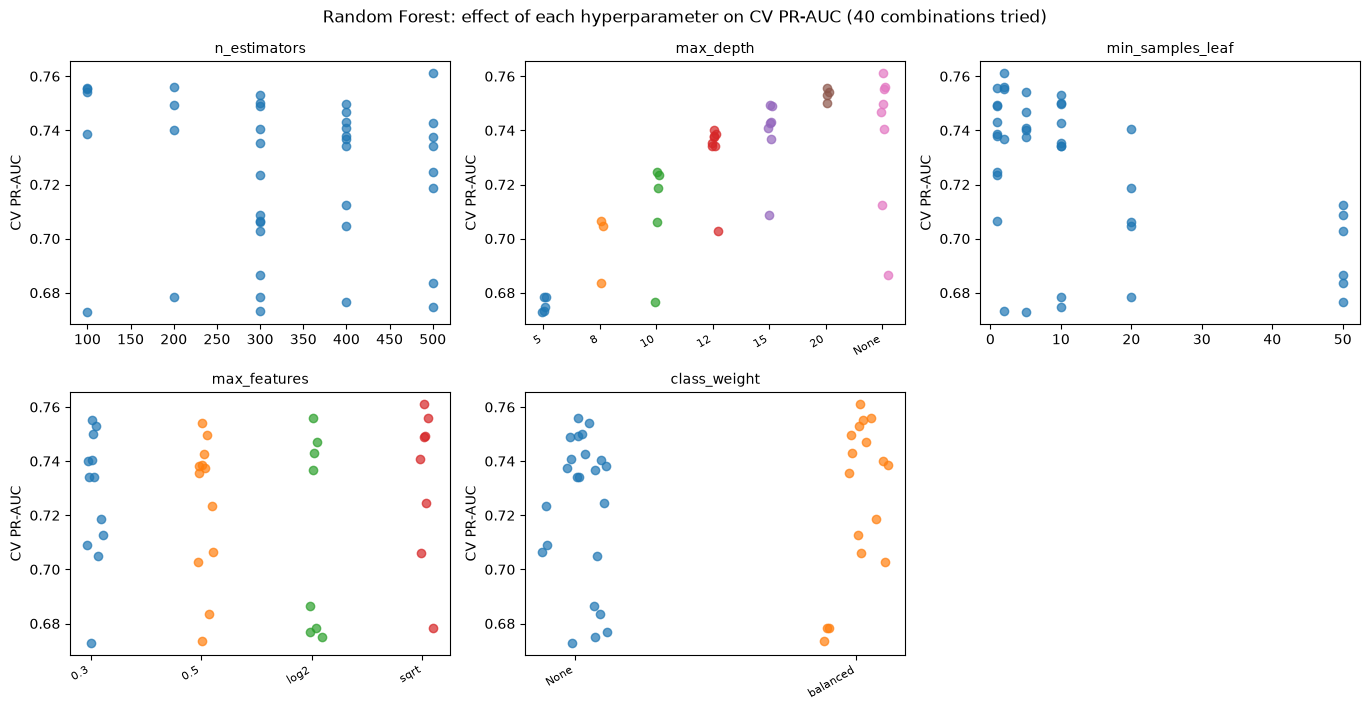

In [10]:
tc.plot_param_effects(MODEL_NAME, search)

## 5. Save results and the tuned model
Writes the CSV / JSON files read by `06e` and saves the tuned model (a plain scikit-learn model) to `models/tuned/`. **No test data is used.**

In [11]:
tc.save_search(MODEL_NAME, search)

{'cv_results': 'C:\\Users\\LOQ\\OneDrive\\Documents\\GitHub\\routeright-reassignment-predictor\\docs\\deliverables_eval2\\tuning\\tuning_random_forest_cv_results.csv',
 'best_folds': 'C:\\Users\\LOQ\\OneDrive\\Documents\\GitHub\\routeright-reassignment-predictor\\docs\\deliverables_eval2\\tuning\\tuning_random_forest_best_folds.csv',
 'summary': 'C:\\Users\\LOQ\\OneDrive\\Documents\\GitHub\\routeright-reassignment-predictor\\docs\\deliverables_eval2\\tuning\\tuning_random_forest_summary.csv',
 'best_json': 'C:\\Users\\LOQ\\OneDrive\\Documents\\GitHub\\routeright-reassignment-predictor\\docs\\deliverables_eval2\\tuning\\tuning_random_forest_best.json',
 'model': 'C:\\Users\\LOQ\\OneDrive\\Documents\\GitHub\\routeright-reassignment-predictor\\models\\tuned\\random_forest_tuned.pkl'}

## 6. Interpretation — feature importance

Best settings: {'n_estimators': 500, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': None, 'class_weight': 'balanced'}


,gini_importance
opened_hour,0.0772
opened_month,0.0549
opened_day_of_week,0.0538
assignment_group_20,0.0469
u_symptom_534,0.0393
opened_by_Other,0.0244
assignment_group_64,0.0224
category_23,0.0223
assignment_group_70,0.0216
u_symptom_Other,0.0174


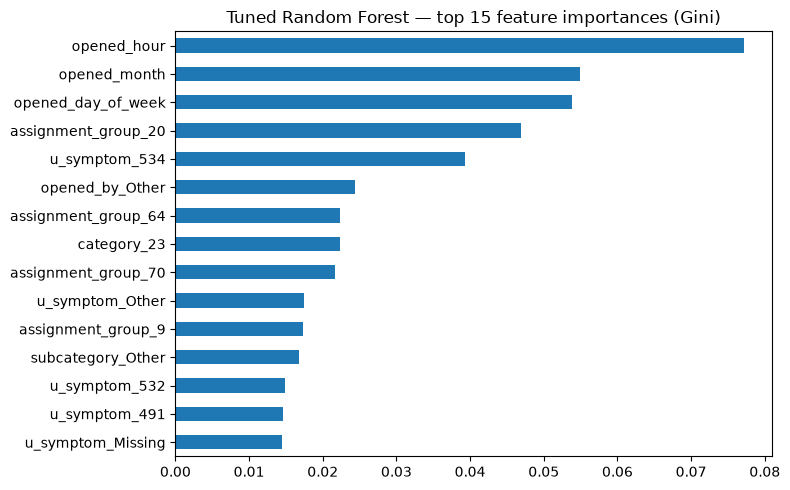

In [12]:
rf = search.best_estimator_
print("Best settings:", tc.clean_params(search.best_params_))
imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(15)
display(imp.round(4).to_frame("gini_importance"))
imp.iloc[::-1].plot.barh(figsize=(8, 5), title="Tuned Random Forest — top 15 feature importances (Gini)")
plt.tight_layout(); plt.savefig(tc.TUNE_DIR / "tuning_random_forest_importance.png", dpi=130); plt.show()

## 7. Observations
*(to be written after the run)*